In [1]:
from pathlib import Path
import io
import re
import subprocess
import pandas as pd
import chess
import chess.pgn
import zstandard as zstd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

DATA_DIR = Path("data/lichess")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Start with an old/smaller month, not a recent 30GB dump.
YEAR = 2013
MONTH = 1

MAX_GAMES_TO_PARSE = 50_000
MAX_POSITIONS_TO_EXTRACT = 200_000

url = f"https://database.lichess.org/standard/lichess_db_standard_rated_{YEAR}-{MONTH:02d}.pgn.zst"
zst_path = DATA_DIR / f"lichess_db_standard_rated_{YEAR}-{MONTH:02d}.pgn.zst"

url, zst_path

('https://database.lichess.org/standard/lichess_db_standard_rated_2013-01.pgn.zst',
 PosixPath('data/lichess/lichess_db_standard_rated_2013-01.pgn.zst'))

In [2]:
import urllib.request

if not zst_path.exists():
    print(f"Downloading: {url}")
    urllib.request.urlretrieve(url, zst_path)
else:
    print(f"Already exists: {zst_path}")

print(f"File size: {zst_path.stat().st_size / 1e9:.2f} GB")

Downloading: https://database.lichess.org/standard/lichess_db_standard_rated_2013-01.pgn.zst
File size: 0.02 GB


In [3]:
def stream_pgn_games_from_zst(path: Path):
    """
    Streams games from a .pgn.zst file without fully decompressing it to disk.
    """
    dctx = zstd.ZstdDecompressor()
    with open(path, "rb") as compressed:
        with dctx.stream_reader(compressed) as reader:
            text_stream = io.TextIOWrapper(reader, encoding="utf-8", errors="replace")
            while True:
                game = chess.pgn.read_game(text_stream)
                if game is None:
                    break
                yield game

In [4]:
rows = []

for i, game in enumerate(tqdm(stream_pgn_games_from_zst(zst_path), total=MAX_GAMES_TO_PARSE)):
    if i >= MAX_GAMES_TO_PARSE:
        break

    h = game.headers

    rows.append({
        "event": h.get("Event"),
        "site": h.get("Site"),
        "date": h.get("Date"),
        "utc_date": h.get("UTCDate"),
        "utc_time": h.get("UTCTime"),
        "white": h.get("White"),
        "black": h.get("Black"),
        "white_elo": h.get("WhiteElo"),
        "black_elo": h.get("BlackElo"),
        "result": h.get("Result"),
        "time_control": h.get("TimeControl"),
        "termination": h.get("Termination"),
        "eco": h.get("ECO"),
        "opening": h.get("Opening"),
        "ply_count": h.get("PlyCount"),
    })

games_df = pd.DataFrame(rows)

games_df.head()

  0%|          | 0/50000 [00:00<?, ?it/s]

,event,site,date,utc_date,utc_time,white,black,white_elo,black_elo,result,time_control,termination,eco,opening,ply_count
0,Rated Classical game,https://lichess.org/j1dkb5dw,????.??.??,2012.12.31,23:01:03,BFG9k,mamalak,1639,1403,1-0,600+8,Normal,C00,French Defense: Normal Variation,None
1,Rated Classical game,https://lichess.org/a9tcp02g,????.??.??,2012.12.31,23:04:12,Desmond_Wilson,savinka59,1654,1919,1-0,480+2,Normal,D04,"Queen's Pawn Game: Colle System, Anti-Colle",None
2,Rated Classical game,https://lichess.org/szom2tog,????.??.??,2012.12.31,23:03:15,Kozakmamay007,VanillaShamanilla,1643,1747,1-0,420+17,Normal,C50,Four Knights Game: Italian Variation,None
3,Rated Bullet game,https://lichess.org/rklpc7mk,????.??.??,2012.12.31,23:04:57,Naitero_Nagasaki,800,1824,1973,0-1,60+1,Normal,B12,Caro-Kann Defense: Goldman Variation,None
4,Rated Bullet game,https://lichess.org/1xb3os63,????.??.??,2012.12.31,23:02:37,nichiren1967,Naitero_Nagasaki,1765,1815,0-1,60+1,Normal,C00,French Defense: La Bourdonnais Variation,None


In [5]:
def to_int_safe(x):
    try:
        return int(x)
    except Exception:
        return None

for col in ["white_elo", "black_elo", "ply_count"]:
    games_df[col] = games_df[col].apply(to_int_safe)

games_df["avg_elo"] = games_df[["white_elo", "black_elo"]].mean(axis=1)

games_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   event         50000 non-null  str    
 1   site          50000 non-null  str    
 2   date          50000 non-null  str    
 3   utc_date      50000 non-null  str    
 4   utc_time      50000 non-null  str    
 5   white         50000 non-null  str    
 6   black         50000 non-null  str    
 7   white_elo     49963 non-null  float64
 8   black_elo     49930 non-null  float64
 9   result        50000 non-null  str    
 10  time_control  50000 non-null  str    
 11  termination   50000 non-null  str    
 12  eco           50000 non-null  str    
 13  opening       50000 non-null  str    
 14  ply_count     0 non-null      object 
 15  avg_elo       50000 non-null  float64
dtypes: float64(3), object(1), str(12)
memory usage: 6.1+ MB


In [6]:
games_df.describe(include="all")

,event,site,date,utc_date,utc_time,white,black,white_elo,black_elo,result,time_control,termination,eco,opening,ply_count,avg_elo
count,50000,50000,50000,50000,50000,50000,50000,49963.000000,49930.000000,50000,50000,50000,50000,50000,0,50000.000000
unique,45,50000,1,14,36939,2611,2544,NaN,NaN,3,313,2,366,1544,0,NaN
top,Rated Blitz game,https://lichess.org/j1dkb5dw,????.??.??,2013.01.04,20:39:54,ChikiPuki,Redneck,NaN,NaN,1-0,60+0,Normal,A00,Van't Kruijs Opening,NaN,NaN
freq,18043,1,50000,4249,7,730,845,NaN,NaN,25590,6837,33978,4103,1895,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1605.551988,1594.749369,NaN,NaN,NaN,NaN,NaN,NaN,1599.645080
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,201.314355,205.765077,NaN,NaN,NaN,NaN,NaN,NaN,176.675075
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,843.000000,800.000000,NaN,NaN,NaN,NaN,NaN,NaN,800.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1479.000000,1467.000000,NaN,NaN,NaN,NaN,NaN,NaN,1480.500000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1601.000000,1586.000000,NaN,NaN,NaN,NaN,NaN,NaN,1591.500000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1736.000000,1728.000000,NaN,NaN,NaN,NaN,NaN,NaN,1715.000000


In [7]:
games_df["result"].value_counts(dropna=False)

result
1-0        25590
0-1        22763
1/2-1/2     1647
Name: count, dtype: int64

In [8]:
games_df["termination"].value_counts(dropna=False).head(20)

termination
Normal          33978
Time forfeit    16022
Name: count, dtype: int64

In [9]:
games_df["time_control"].value_counts(dropna=False).head(20)

time_control
60+0     6837
300+0    4035
180+0    3445
120+0    2986
0+1      2575
300+8    2436
300+5    1686
180+3    1664
240+0    1591
600+0    1138
300+2    1081
60+1     1022
420+0     731
900+0     703
300+3     674
360+0     573
480+0     564
480+8     512
180+2     511
180+1     432
Name: count, dtype: int64

In [10]:
games_df["opening"].value_counts(dropna=False).head(30)

opening
Van't Kruijs Opening                             1895
Owen Defense                                     1177
Scandinavian Defense: Mieses-Kotroc Variation     983
Modern Defense                                    919
Horwitz Defense                                   804
French Defense: Knight Variation                  804
Queen's Pawn Game: Chigorin Variation             749
Philidor Defense #3                               738
Sicilian Defense: Bowdler Attack                  703
Scandinavian Defense                              682
Hungarian Opening                                 670
King's Pawn Game: Wayward Queen Attack            650
Caro-Kann Defense                                 582
Sicilian Defense                                  576
Queen's Pawn Game #2                              574
Queen's Pawn Game                                 560
English Defense #2                                534
Bishop's Opening                                  533
Philidor Defense #2 

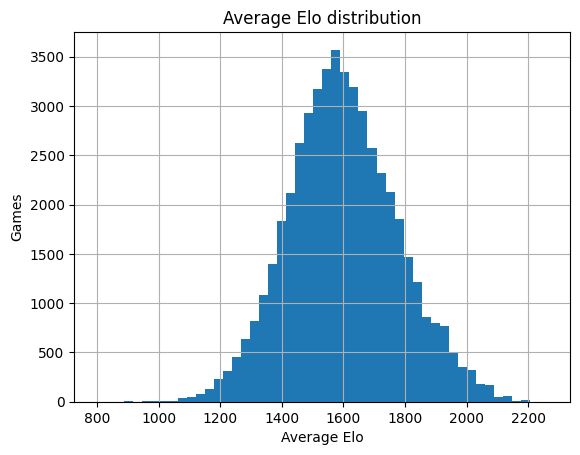

In [11]:
games_df["avg_elo"].dropna().hist(bins=50)
plt.title("Average Elo distribution")
plt.xlabel("Average Elo")
plt.ylabel("Games")
plt.show()

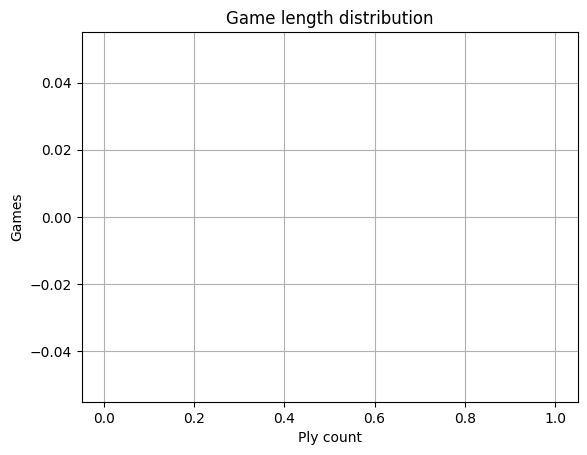

In [12]:
games_df["ply_count"].dropna().hist(bins=80)
plt.title("Game length distribution")
plt.xlabel("Ply count")
plt.ylabel("Games")
plt.show()

In [13]:
position_rows = []
position_count = 0

for game_idx, game in enumerate(tqdm(stream_pgn_games_from_zst(zst_path), total=MAX_GAMES_TO_PARSE)):
    if game_idx >= MAX_GAMES_TO_PARSE:
        break
    if position_count >= MAX_POSITIONS_TO_EXTRACT:
        break

    board = game.board()
    h = game.headers

    white_elo = to_int_safe(h.get("WhiteElo"))
    black_elo = to_int_safe(h.get("BlackElo"))

    for ply_idx, move in enumerate(game.mainline_moves(), start=1):
        if position_count >= MAX_POSITIONS_TO_EXTRACT:
            break

        # Position BEFORE the move.
        fen_before = board.fen()
        san = board.san(move)
        uci = move.uci()

        position_rows.append({
            "game_idx": game_idx,
            "ply": ply_idx,
            "fullmove_number": board.fullmove_number,
            "side_to_move": "white" if board.turn == chess.WHITE else "black",
            "fen": fen_before,
            "move_uci": uci,
            "move_san": san,
            "result": h.get("Result"),
            "white_elo": white_elo,
            "black_elo": black_elo,
            "avg_elo": None if white_elo is None or black_elo is None else (white_elo + black_elo) / 2,
            "time_control": h.get("TimeControl"),
            "eco": h.get("ECO"),
            "opening": h.get("Opening"),
        })

        board.push(move)
        position_count += 1

positions_df = pd.DataFrame(position_rows)
positions_df.head()

  0%|          | 0/50000 [00:00<?, ?it/s]

,game_idx,ply,fullmove_number,side_to_move,fen,move_uci,move_san,result,white_elo,black_elo,avg_elo,time_control,eco,opening
0,0,1,1,white,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,e2e4,e4,1-0,1639,1403.0,1521.0,600+8,C00,French Defense: Normal Variation
1,0,2,1,black,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,e7e6,e6,1-0,1639,1403.0,1521.0,600+8,C00,French Defense: Normal Variation
2,0,3,2,white,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,d2d4,d4,1-0,1639,1403.0,1521.0,600+8,C00,French Defense: Normal Variation
3,0,4,2,black,rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...,b7b6,b6,1-0,1639,1403.0,1521.0,600+8,C00,French Defense: Normal Variation
4,0,5,3,white,rnbqkbnr/p1pp1ppp/1p2p3/8/3PP3/8/PPP2PPP/RNBQK...,a2a3,a3,1-0,1639,1403.0,1521.0,600+8,C00,French Defense: Normal Variation


In [14]:
PIECE_VALUES = {
    chess.PAWN: 1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK: 5,
    chess.QUEEN: 9,
    chess.KING: 0,
}

def material_balance(board: chess.Board):
    white = 0
    black = 0
    for piece_type, value in PIECE_VALUES.items():
        white += len(board.pieces(piece_type, chess.WHITE)) * value
        black += len(board.pieces(piece_type, chess.BLACK)) * value
    return white - black

def legal_mobility(board: chess.Board):
    return board.legal_moves.count()

def open_file_count(board: chess.Board):
    count = 0
    for file_idx in range(8):
        has_pawn = False
        for rank_idx in range(8):
            square = chess.square(file_idx, rank_idx)
            piece = board.piece_at(square)
            if piece and piece.piece_type == chess.PAWN:
                has_pawn = True
                break
        if not has_pawn:
            count += 1
    return count

def semi_open_file_count(board: chess.Board):
    count = 0
    for file_idx in range(8):
        white_pawn = False
        black_pawn = False
        for rank_idx in range(8):
            square = chess.square(file_idx, rank_idx)
            piece = board.piece_at(square)
            if piece and piece.piece_type == chess.PAWN:
                if piece.color == chess.WHITE:
                    white_pawn = True
                else:
                    black_pawn = True
        if white_pawn != black_pawn:
            count += 1
    return count

def phase_proxy(board: chess.Board):
    queens = len(board.pieces(chess.QUEEN, chess.WHITE)) + len(board.pieces(chess.QUEEN, chess.BLACK))
    total_material = sum(
        len(board.pieces(pt, chess.WHITE)) * v + len(board.pieces(pt, chess.BLACK)) * v
        for pt, v in PIECE_VALUES.items()
    )

    if board.fullmove_number <= 10:
        return "opening"
    if queens == 0 and total_material <= 28:
        return "endgame"
    return "middlegame"

def extract_light_features(fen: str):
    board = chess.Board(fen)
    return {
        "material_balance": material_balance(board),
        "legal_mobility": legal_mobility(board),
        "open_files": open_file_count(board),
        "semi_open_files": semi_open_file_count(board),
        "is_check": board.is_check(),
        "phase_proxy": phase_proxy(board),
    }

features_df = pd.DataFrame([extract_light_features(fen) for fen in tqdm(positions_df["fen"])])
positions_features_df = pd.concat([positions_df, features_df], axis=1)

positions_features_df.head()

  0%|          | 0/200000 [00:00<?, ?it/s]

,game_idx,ply,fullmove_number,side_to_move,fen,move_uci,move_san,result,white_elo,black_elo,avg_elo,time_control,eco,opening,material_balance,legal_mobility,open_files,semi_open_files,is_check,phase_proxy
0,0,1,1,white,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,e2e4,e4,1-0,1639,1403.0,1521.0,600+8,C00,French Defense: Normal Variation,0,20,0,0,False,opening
1,0,2,1,black,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,e7e6,e6,1-0,1639,1403.0,1521.0,600+8,C00,French Defense: Normal Variation,0,20,0,0,False,opening
2,0,3,2,white,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,d2d4,d4,1-0,1639,1403.0,1521.0,600+8,C00,French Defense: Normal Variation,0,30,0,0,False,opening
3,0,4,2,black,rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...,b7b6,b6,1-0,1639,1403.0,1521.0,600+8,C00,French Defense: Normal Variation,0,30,0,0,False,opening
4,0,5,3,white,rnbqkbnr/p1pp1ppp/1p2p3/8/3PP3/8/PPP2PPP/RNBQK...,a2a3,a3,1-0,1639,1403.0,1521.0,600+8,C00,French Defense: Normal Variation,0,38,0,0,False,opening


In [15]:
positions_features_df["phase_proxy"].value_counts(normalize=True)

phase_proxy
middlegame    0.552945
opening       0.298295
endgame       0.148760
Name: proportion, dtype: float64

In [16]:
positions_features_df[["material_balance", "legal_mobility", "open_files", "semi_open_files"]].describe()

,material_balance,legal_mobility,open_files,semi_open_files
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,-0.009325,29.207260,1.243415,1.856665
std,4.139959,11.797506,1.634823,1.486140
min,-39.000000,1.000000,0.000000,0.000000
25%,-1.000000,23.000000,0.000000,0.000000
50%,0.000000,31.000000,1.000000,2.000000
75%,1.000000,37.000000,2.000000,3.000000
max,40.000000,88.000000,8.000000,8.000000


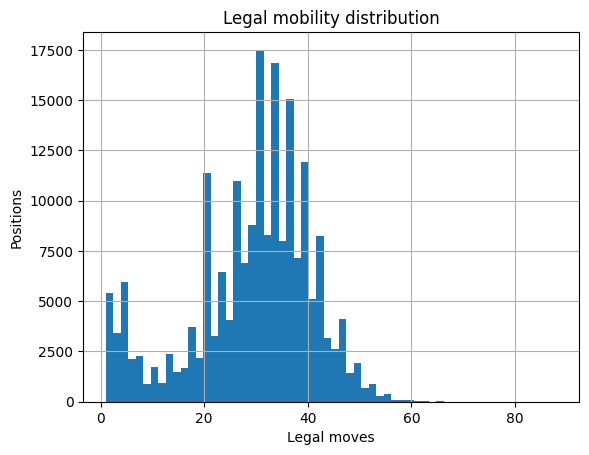

In [17]:
positions_features_df["legal_mobility"].hist(bins=60)
plt.title("Legal mobility distribution")
plt.xlabel("Legal moves")
plt.ylabel("Positions")
plt.show()

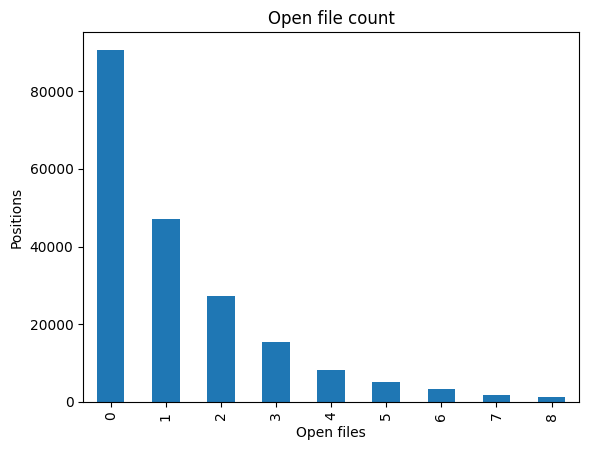

In [18]:
positions_features_df["open_files"].value_counts().sort_index().plot(kind="bar")
plt.title("Open file count")
plt.xlabel("Open files")
plt.ylabel("Positions")
plt.show()

In [19]:
import numpy as np

PIECE_TO_CHANNEL = {
    (chess.PAWN, chess.WHITE): 0,
    (chess.KNIGHT, chess.WHITE): 1,
    (chess.BISHOP, chess.WHITE): 2,
    (chess.ROOK, chess.WHITE): 3,
    (chess.QUEEN, chess.WHITE): 4,
    (chess.KING, chess.WHITE): 5,
    (chess.PAWN, chess.BLACK): 6,
    (chess.KNIGHT, chess.BLACK): 7,
    (chess.BISHOP, chess.BLACK): 8,
    (chess.ROOK, chess.BLACK): 9,
    (chess.QUEEN, chess.BLACK): 10,
    (chess.KING, chess.BLACK): 11,
}

def board_to_tensor(fen: str):
    board = chess.Board(fen)
    x = np.zeros((18, 8, 8), dtype=np.float32)

    for square, piece in board.piece_map().items():
        channel = PIECE_TO_CHANNEL[(piece.piece_type, piece.color)]
        rank = chess.square_rank(square)
        file = chess.square_file(square)
        x[channel, rank, file] = 1.0

    # Side to move.
    x[12, :, :] = 1.0 if board.turn == chess.WHITE else 0.0

    # Castling rights.
    x[13, :, :] = 1.0 if board.has_kingside_castling_rights(chess.WHITE) else 0.0
    x[14, :, :] = 1.0 if board.has_queenside_castling_rights(chess.WHITE) else 0.0
    x[15, :, :] = 1.0 if board.has_kingside_castling_rights(chess.BLACK) else 0.0
    x[16, :, :] = 1.0 if board.has_queenside_castling_rights(chess.BLACK) else 0.0

    # Normalized fullmove number, clipped.
    x[17, :, :] = min(board.fullmove_number, 100) / 100.0

    return x

sample_tensor = board_to_tensor(positions_features_df.iloc[0]["fen"])
sample_tensor.shape

(18, 8, 8)

## Position Style Encoder

ResNet trunk → 128-d L2-normalised embedding `z`, distilled from the existing Stockfish feature pipeline via 4 multitask heads:

| Head | Target | Loss |
|---|---|---|
| `style` | 9 × `MATCHER_COLUMNS_V2` features `[0,1]` | MSE |
| `phase` | opening / middlegame / endgame | CE |
| `eval` | winning / equal / losing (±200cp) | CE (Stockfish mode only) |
| `tactic` | tactical + quiet_middlegame (+ 8 themes in Stockfish mode) | BCE |

Set `LABEL_MODE = "lightweight"` (fast, no engine) or `"stockfish"` (full quality).

In [ ]:
import torch
from utils.position_style_encoder import _get_device

LABEL_MODE = "lightweight"   # switch to "stockfish" for engine-quality labels
DEVICE = _get_device()

print(f"Label mode : {LABEL_MODE}")
print(f"Device     : {DEVICE}")
print(f"PyTorch    : {torch.__version__}")

In [ ]:
from pathlib import Path
from utils.position_label_builder import build_labels

LABELS_CACHE = Path(f"data/labels_{LABEL_MODE}.parquet")

# positions_df and board_to_tensor come from earlier cells in this notebook
# Build (or reload) per-position labels
labels_df = build_labels(
    positions_df,
    mode=LABEL_MODE,
    cache_path=LABELS_CACHE,
)

print("Labels shape :", labels_df.shape)
print("Phase distribution:")
print(labels_df["phase_idx"].map({0: "opening", 1: "middlegame", 2: "endgame"}).value_counts())
print("\nTactical distribution:")
print(labels_df["tactic_tactical"].value_counts())
labels_df.head(3)

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
from utils.position_style_encoder import (
    PositionStyleEncoder,
    PositionStyleDataset,
    train_one_epoch,
    evaluate,
    save_checkpoint,
)

# ---- Precompute board tensors for all positions ----
# board_to_tensor is defined earlier in this notebook
tensors_all = np.stack([board_to_tensor(fen) for fen in tqdm(positions_df["fen"], desc="tensors")])
print("Tensor array:", tensors_all.shape)

# ---- Dataset & splits ----
dataset = PositionStyleDataset(tensors_all, labels_df, mode=LABEL_MODE)
n_train = int(0.85 * len(dataset))
n_val   = len(dataset) - n_train
train_ds, val_ds = random_split(dataset, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=0)

print(f"Train: {n_train}  Val: {n_val}")

# ---- Model ----
model = PositionStyleEncoder(mode=LABEL_MODE)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# ---- Training loop ----
N_EPOCHS = 30
CKPT_PATH = Path(f"data/encoder_{LABEL_MODE}.pt")

history = []
for epoch in range(1, N_EPOCHS + 1):
    tr = train_one_epoch(model, train_loader, optimizer, DEVICE)
    vl = evaluate(model, val_loader, DEVICE)
    scheduler.step()
    history.append({"epoch": epoch, **{f"train_{k}": v for k, v in tr.items()},
                                     **{f"val_{k}":   v for k, v in vl.items()}})
    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d} | "
              f"train total={tr['total']:.4f}  style={tr['style']:.4f}  "
              f"phase={tr['phase']:.4f}  tactic={tr['tactic']:.4f} | "
              f"val total={vl['total']:.4f}")

save_checkpoint(model, optimizer, N_EPOCHS, history[-1], CKPT_PATH)
print("Training complete.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, col in zip(axes, ["total", "style", "phase", "tactic"]):
    ax.plot(hist_df["epoch"], hist_df[f"train_{col}"], label="train")
    ax.plot(hist_df["epoch"], hist_df[f"val_{col}"],   label="val", linestyle="--")
    ax.set_title(col)
    ax.set_xlabel("epoch")
    ax.legend()
plt.suptitle("Loss curves", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
## Embedding geometry sanity check (UMAP / PCA)
# pip install umap-learn  ← if you want UMAP; falls back to PCA automatically

import numpy as np
import matplotlib.pyplot as plt
from utils.position_style_encoder import embed_positions

# Embed the full set
embeddings = embed_positions(model, tensors_all, batch_size=512, device=DEVICE)
print("Embeddings:", embeddings.shape)

# Reduce to 2-D
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
    coords = reducer.fit_transform(embeddings)
    method = "UMAP"
except ImportError:
    from sklearn.decomposition import PCA
    coords = PCA(n_components=2).fit_transform(embeddings)
    method = "PCA"

phase_names = {0: "opening", 1: "middlegame", 2: "endgame"}
colors_phase = labels_df["phase_idx"].map({0: "steelblue", 1: "darkorange", 2: "seagreen"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coloured by phase
ax = axes[0]
for idx, (label, color) in enumerate({0: "steelblue", 1: "darkorange", 2: "seagreen"}.items()):
    mask = labels_df["phase_idx"] == idx
    ax.scatter(coords[mask, 0], coords[mask, 1], c=color,
               label=phase_names[idx], alpha=0.5, s=8)
ax.set_title(f"{method} coloured by phase")
ax.legend(markerscale=2)

# Coloured by tactic
ax = axes[1]
c_tactic = labels_df["tactic_tactical"].map({0: "royalblue", 1: "crimson"})
ax.scatter(coords[:, 0], coords[:, 1], c=c_tactic, alpha=0.5, s=8)
ax.scatter([], [], c="royalblue", label="quiet")
ax.scatter([], [], c="crimson",   label="tactical")
ax.set_title(f"{method} coloured by tactical flag")
ax.legend(markerscale=2)

plt.tight_layout()
plt.show()

In [ ]:
## Single-board inference demo
import chess
import numpy as np
import torch
from utils.position_style_encoder import load_checkpoint
from utils.opening_feature_transformer import MATCHER_COLUMNS_V2

# Load the saved checkpoint
model_loaded, ckpt_meta = load_checkpoint(CKPT_PATH, device=DEVICE)
model_loaded.eval()

PHASE_NAMES  = ["opening", "middlegame", "endgame"]
EVAL_NAMES   = ["losing",  "equal",      "winning"]

def encode_fen(fen: str) -> dict:
    """Encode a single FEN → embedding z + predicted style, phase, eval, tactic."""
    t = torch.from_numpy(board_to_tensor(fen)).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        out = model_loaded(t)

    z      = out["z"].cpu().numpy()[0]
    style  = torch.sigmoid(out["style"]).cpu().numpy()[0]
    phase  = torch.softmax(out["phase"], dim=-1).cpu().numpy()[0]
    ev     = torch.softmax(out["eval"],  dim=-1).cpu().numpy()[0]
    tactic = torch.sigmoid(out["tactic"]).cpu().numpy()[0]

    return {
        "z":            z,
        "style":        dict(zip(MATCHER_COLUMNS_V2, style.tolist())),
        "phase":        dict(zip(PHASE_NAMES, phase.tolist())),
        "eval":         dict(zip(EVAL_NAMES, ev.tolist())),
        "tactic_prob":  tactic.tolist(),  # [tactical, quiet_middlegame]
    }

# --- Demo: starting position ---
starting = "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1"
result = encode_fen(starting)

print("=== Starting position ===")
print(f"Phase  : {max(result['phase'], key=result['phase'].get)} {result['phase']}")
print(f"Eval   : {max(result['eval'],  key=result['eval'].get)}  {result['eval']}")
print(f"Tactic : {result['tactic_prob']}")
print("Style vector:")
for k, v in result["style"].items():
    print(f"  {k:35s}: {v:.3f}")
print(f"z norm : {float(np.linalg.norm(result['z'])):.6f}  (should be 1.0)")

# --- Demo: a sharp middlegame FEN ---
sharp = "r1bq1rk1/pp2ppbp/2np1np1/8/3NP3/2N1BP2/PPPQ2PP/R3KB1R w KQ - 0 9"
result2 = encode_fen(sharp)
print("\n=== Sharp King's Indian middlegame ===")
print(f"Phase  : {max(result2['phase'], key=result2['phase'].get)}")
print(f"Tactic prob (tactical, quiet_mg): {result2['tactic_prob']}")
print("Style vector:")
for k, v in result2["style"].items():
    print(f"  {k:35s}: {v:.3f}")